<a href="https://colab.research.google.com/github/piyushyadav112233/random-forest-/blob/main/decision_tree_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
# Additional imports for visualization and other models
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [2]:
df = pd.read_csv('/content/decision_tree_dataset.csv')
df.head()

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Loan_Approval
0,56,54674,Bachelors,Self-Employed,Divorced,427,Denied
1,69,55854,Masters,Self-Employed,Married,751,Approved
2,46,66271,PhD,Employed,Single,668,Denied
3,32,93688,High School,Employed,Divorced,342,Approved
4,60,58518,PhD,Self-Employed,Widowed,718,Approved


In [3]:
# Data Exploration and Preprocessing
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Income             1000 non-null   int64 
 2   Education          1000 non-null   object
 3   Employment_Status  1000 non-null   object
 4   Marital_Status     1000 non-null   object
 5   Credit_Score       1000 non-null   int64 
 6   Loan_Approval      1000 non-null   object
dtypes: int64(3), object(4)
memory usage: 54.8+ KB


In [4]:
print(df.head())
print(df.info())
print(df.describe())




   Age  Income    Education Employment_Status Marital_Status  Credit_Score  \
0   56   54674    Bachelors     Self-Employed       Divorced           427   
1   69   55854      Masters     Self-Employed        Married           751   
2   46   66271          PhD          Employed         Single           668   
3   32   93688  High School          Employed       Divorced           342   
4   60   58518          PhD     Self-Employed        Widowed           718   

  Loan_Approval  
0        Denied  
1      Approved  
2        Denied  
3      Approved  
4      Approved  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Income             1000 non-null   int64 
 2   Education          1000 non-null   object
 3   Employment_Status  1000 non-null   object
 4   Marital_Status     1000 non-nul

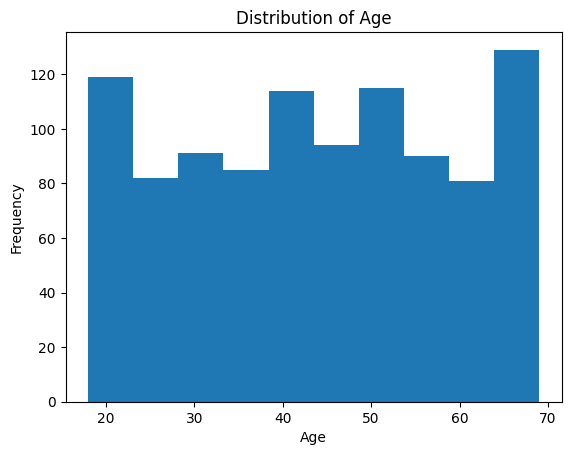

In [5]:
#historgram
# Assuming 'Age' is a column in your DataFrame
plt.hist(df['Age'])  # Changed column name to 'Age'
plt.title('Distribution of Age') # Changed title to reflect column
plt.xlabel('Age') # Changed x-axis label
plt.ylabel('Frequency')
plt.show()

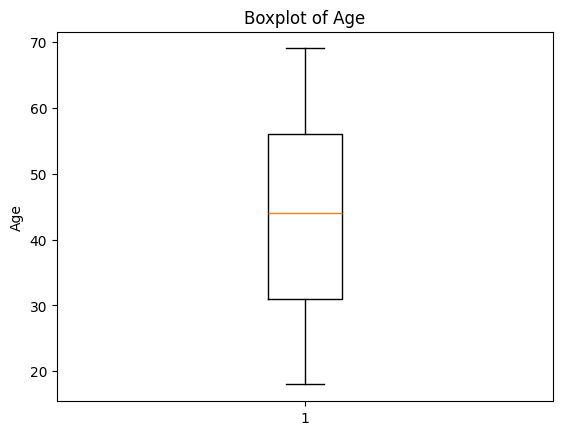

In [6]:
#boxplot
plt.boxplot(df['Age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()

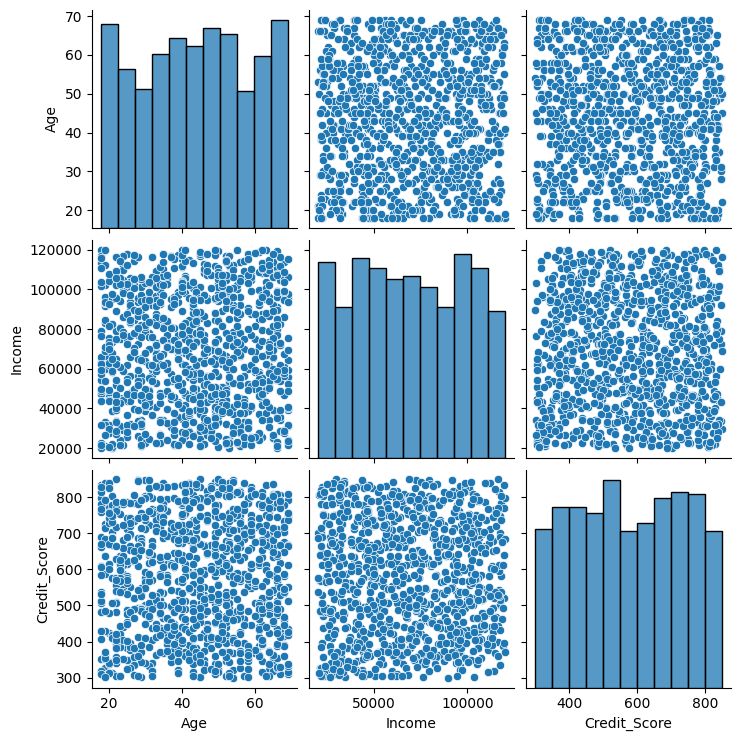

In [7]:
import seaborn as sns
sns.pairplot(df)
plt.show()

Index(['Age', 'Income', 'Education', 'Employment_Status', 'Marital_Status',
       'Credit_Score', 'Loan_Approval'],
      dtype='object')


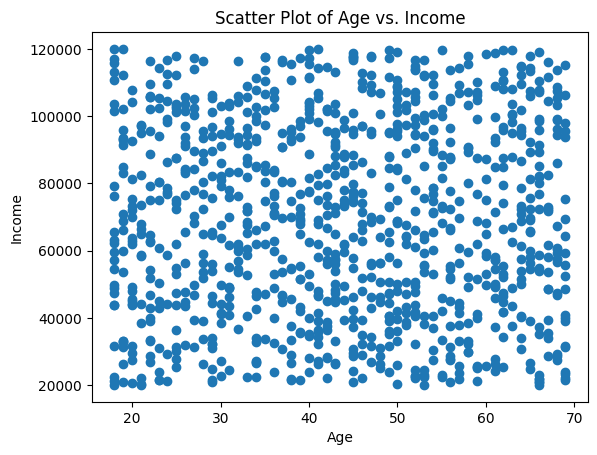

In [8]:
# Print the column names to check for typos or missing columns
print(df.columns)

# Assuming the correct column name is 'Income' (from your global variables),
# Update your scatter plot code
plt.scatter(df['Age'], df['Income'])
plt.title('Scatter Plot of Age vs. Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [9]:
#missing value
df.isnull().sum()

,0
Age,0
Income,0
Education,0
Employment_Status,0
Marital_Status,0
Credit_Score,0
Loan_Approval,0


In [10]:
df.corr(numeric_only=True)

,Age,Income,Credit_Score
Age,1.000000,0.002786,-0.013301
Income,0.002786,1.000000,0.018185
Credit_Score,-0.013301,0.018185,1.000000


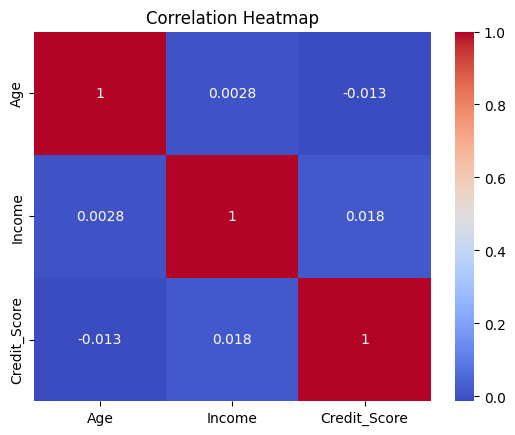

In [11]:
#heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
# Option 2: Use 'agg' for custom aggregations
df[['Income','Credit_Score']].agg(['mean', 'min', 'max'])

,Income,Credit_Score
mean,69127.035,576.874
min,20060.000,300.000
max,119986.000,849.000


In [13]:
# Option 3: Group and aggregate data\
df.groupby('Age')['Income'].agg(['mean', 'min', 'max','std'])

,mean,min,max,std
Age,,,,
18,67837.625000,20077,119929,32593.298010
19,69820.190476,20846,119911,30623.385013
20,59529.238095,20526,107833,24473.876178
21,60455.000000,20126,97475,26920.825645
22,68317.739130,26960,116523,29977.961941
23,63307.800000,21435,114377,32320.647077
24,79532.928571,21342,116809,30891.496822
25,69008.476190,25415,117829,30575.696912
26,76584.352941,31954,105655,23677.550947


In [14]:
#Feature Engineering and Selection:
df['Age_Income_Combined'] = df['Age'] * df['Income']  # Example: Interaction term
df['Age_Squared'] = df['Age'] ** 2  # Example: Non-linear transformation
df['Age_Income_Ratio'] = df['Age'] / df['Income']
# 2. Income Category (Binning Income)
income_bins = [0, 30000, 60000, 90000, 120000, float('inf')]  # Define income bins
income_labels = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']
df['Income_Category'] = pd.cut(df['Income'], bins=income_bins, labels=income_labels)
print(df.head())


   Age  Income    Education Employment_Status Marital_Status  Credit_Score  \
0   56   54674    Bachelors     Self-Employed       Divorced           427   
1   69   55854      Masters     Self-Employed        Married           751   
2   46   66271          PhD          Employed         Single           668   
3   32   93688  High School          Employed       Divorced           342   
4   60   58518          PhD     Self-Employed        Widowed           718   

  Loan_Approval  Age_Income_Combined  Age_Squared  Age_Income_Ratio  \
0        Denied              3061744         3136          0.001024   
1      Approved              3853926         4761          0.001235   
2        Denied              3048466         2116          0.000694   
3      Approved              2998016         1024          0.000342   
4      Approved              3511080         3600          0.001025   

  Income_Category  
0    Lower-Middle  
1    Lower-Middle  
2          Middle  
3    Upper-Middle  
4   

In [15]:
# 3. Credit Score to Income Ratio
df['Credit_Score_Income_Ratio'] = df['Credit_Score'] / df['Income']
print(df.head())

   Age  Income    Education Employment_Status Marital_Status  Credit_Score  \
0   56   54674    Bachelors     Self-Employed       Divorced           427   
1   69   55854      Masters     Self-Employed        Married           751   
2   46   66271          PhD          Employed         Single           668   
3   32   93688  High School          Employed       Divorced           342   
4   60   58518          PhD     Self-Employed        Widowed           718   

  Loan_Approval  Age_Income_Combined  Age_Squared  Age_Income_Ratio  \
0        Denied              3061744         3136          0.001024   
1      Approved              3853926         4761          0.001235   
2        Denied              3048466         2116          0.000694   
3      Approved              2998016         1024          0.000342   
4      Approved              3511080         3600          0.001025   

  Income_Category  Credit_Score_Income_Ratio  
0    Lower-Middle                   0.007810  
1    Lower

In [16]:
df

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Loan_Approval,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Income_Category,Credit_Score_Income_Ratio
0,56,54674,Bachelors,Self-Employed,Divorced,427,Denied,3061744,3136,0.001024,Lower-Middle,0.007810
1,69,55854,Masters,Self-Employed,Married,751,Approved,3853926,4761,0.001235,Lower-Middle,0.013446
2,46,66271,PhD,Employed,Single,668,Denied,3048466,2116,0.000694,Middle,0.010080
3,32,93688,High School,Employed,Divorced,342,Approved,2998016,1024,0.000342,Upper-Middle,0.003650
4,60,58518,PhD,Self-Employed,Widowed,718,Approved,3511080,3600,0.001025,Lower-Middle,0.012270
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,118393,High School,Self-Employed,Married,675,Approved,7103580,3600,0.000507,Upper-Middle,0.005701
996,64,70861,PhD,Self-Employed,Divorced,746,Approved,4535104,4096,0.000903,Middle,0.010528
997,62,95897,High School,Self-Employed,Widowed,405,Denied,5945614,3844,0.000647,Upper-Middle,0.004223
998,35,101905,PhD,Employed,Widowed,700,Approved,3566675,1225,0.000343,Upper-Middle,0.006869


In [17]:
# 4. Credit Score Category (Binning)
bins = [0, 600, 700, 800, 900]  # Define your credit score bins
labels = ['Poor', 'Fair', 'Good', 'Excellent']
df['Credit_Score_Category'] = pd.cut(df['Credit_Score'], bins=bins, labels=labels)
print(df.head())



   Age  Income    Education Employment_Status Marital_Status  Credit_Score  \
0   56   54674    Bachelors     Self-Employed       Divorced           427   
1   69   55854      Masters     Self-Employed        Married           751   
2   46   66271          PhD          Employed         Single           668   
3   32   93688  High School          Employed       Divorced           342   
4   60   58518          PhD     Self-Employed        Widowed           718   

  Loan_Approval  Age_Income_Combined  Age_Squared  Age_Income_Ratio  \
0        Denied              3061744         3136          0.001024   
1      Approved              3853926         4761          0.001235   
2        Denied              3048466         2116          0.000694   
3      Approved              2998016         1024          0.000342   
4      Approved              3511080         3600          0.001025   

  Income_Category  Credit_Score_Income_Ratio Credit_Score_Category  
0    Lower-Middle                  

In [18]:
df

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Loan_Approval,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Income_Category,Credit_Score_Income_Ratio,Credit_Score_Category
0,56,54674,Bachelors,Self-Employed,Divorced,427,Denied,3061744,3136,0.001024,Lower-Middle,0.007810,Poor
1,69,55854,Masters,Self-Employed,Married,751,Approved,3853926,4761,0.001235,Lower-Middle,0.013446,Good
2,46,66271,PhD,Employed,Single,668,Denied,3048466,2116,0.000694,Middle,0.010080,Fair
3,32,93688,High School,Employed,Divorced,342,Approved,2998016,1024,0.000342,Upper-Middle,0.003650,Poor
4,60,58518,PhD,Self-Employed,Widowed,718,Approved,3511080,3600,0.001025,Lower-Middle,0.012270,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,118393,High School,Self-Employed,Married,675,Approved,7103580,3600,0.000507,Upper-Middle,0.005701,Fair
996,64,70861,PhD,Self-Employed,Divorced,746,Approved,4535104,4096,0.000903,Middle,0.010528,Good
997,62,95897,High School,Self-Employed,Widowed,405,Denied,5945614,3844,0.000647,Upper-Middle,0.004223,Poor
998,35,101905,PhD,Employed,Widowed,700,Approved,3566675,1225,0.000343,Upper-Middle,0.006869,Fair


In [19]:
# One-Hot Encoding for Categorical Features
df = pd.get_dummies(df, columns=['Income_Category', 'Credit_Score_Category'], drop_first=True)
print(df.head())

   Age  Income    Education Employment_Status Marital_Status  Credit_Score  \
0   56   54674    Bachelors     Self-Employed       Divorced           427   
1   69   55854      Masters     Self-Employed        Married           751   
2   46   66271          PhD          Employed         Single           668   
3   32   93688  High School          Employed       Divorced           342   
4   60   58518          PhD     Self-Employed        Widowed           718   

  Loan_Approval  Age_Income_Combined  Age_Squared  Age_Income_Ratio  \
0        Denied              3061744         3136          0.001024   
1      Approved              3853926         4761          0.001235   
2        Denied              3048466         2116          0.000694   
3      Approved              2998016         1024          0.000342   
4      Approved              3511080         3600          0.001025   

   Credit_Score_Income_Ratio  Income_Category_Lower-Middle  \
0                   0.007810              

In [20]:
#value count
df['Credit_Score_Category_Good'].value_counts()

,count
Credit_Score_Category_Good,
False,804
True,196


In [21]:
df['Loan_Approval'].value_counts()

,count
Loan_Approval,
Denied,503
Approved,497


In [22]:
#display column names
columns=list(df.columns)
columns

['Age',
 'Income',
 'Education',
 'Employment_Status',
 'Marital_Status',
 'Credit_Score',
 'Loan_Approval',
 'Age_Income_Combined',
 'Age_Squared',
 'Age_Income_Ratio',
 'Credit_Score_Income_Ratio',
 'Income_Category_Lower-Middle',
 'Income_Category_Middle',
 'Income_Category_Upper-Middle',
 'Income_Category_High',
 'Credit_Score_Category_Fair',
 'Credit_Score_Category_Good',
 'Credit_Score_Category_Excellent']

In [23]:
numric_df=df.select_dtypes(include=['number'])
numric_df

,Age,Income,Credit_Score,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Credit_Score_Income_Ratio
0,56,54674,427,3061744,3136,0.001024,0.007810
1,69,55854,751,3853926,4761,0.001235,0.013446
2,46,66271,668,3048466,2116,0.000694,0.010080
3,32,93688,342,2998016,1024,0.000342,0.003650
4,60,58518,718,3511080,3600,0.001025,0.012270
...,...,...,...,...,...,...,...
995,60,118393,675,7103580,3600,0.000507,0.005701
996,64,70861,746,4535104,4096,0.000903,0.010528
997,62,95897,405,5945614,3844,0.000647,0.004223
998,35,101905,700,3566675,1225,0.000343,0.006869


In [24]:
df

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Loan_Approval,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Credit_Score_Income_Ratio,Income_Category_Lower-Middle,Income_Category_Middle,Income_Category_Upper-Middle,Income_Category_High,Credit_Score_Category_Fair,Credit_Score_Category_Good,Credit_Score_Category_Excellent
0,56,54674,Bachelors,Self-Employed,Divorced,427,Denied,3061744,3136,0.001024,0.007810,True,False,False,False,False,False,False
1,69,55854,Masters,Self-Employed,Married,751,Approved,3853926,4761,0.001235,0.013446,True,False,False,False,False,True,False
2,46,66271,PhD,Employed,Single,668,Denied,3048466,2116,0.000694,0.010080,False,True,False,False,True,False,False
3,32,93688,High School,Employed,Divorced,342,Approved,2998016,1024,0.000342,0.003650,False,False,True,False,False,False,False
4,60,58518,PhD,Self-Employed,Widowed,718,Approved,3511080,3600,0.001025,0.012270,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,118393,High School,Self-Employed,Married,675,Approved,7103580,3600,0.000507,0.005701,False,False,True,False,True,False,False
996,64,70861,PhD,Self-Employed,Divorced,746,Approved,4535104,4096,0.000903,0.010528,False,True,False,False,False,True,False
997,62,95897,High School,Self-Employed,Widowed,405,Denied,5945614,3844,0.000647,0.004223,False,False,True,False,False,False,False
998,35,101905,PhD,Employed,Widowed,700,Approved,3566675,1225,0.000343,0.006869,False,False,True,False,True,False,False


In [25]:
#one hot encoded
for column in['Education','Employment_Status','Marital_Status','Loan_Approval']:
  df[column]=LabelEncoder().fit_transform(df[column])
  print(df[column].unique())

[0 2 3 1]
[1 0 2]
[0 1 2 3]
[1 0]


In [26]:
df

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Loan_Approval,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Credit_Score_Income_Ratio,Income_Category_Lower-Middle,Income_Category_Middle,Income_Category_Upper-Middle,Income_Category_High,Credit_Score_Category_Fair,Credit_Score_Category_Good,Credit_Score_Category_Excellent
0,56,54674,0,1,0,427,1,3061744,3136,0.001024,0.007810,True,False,False,False,False,False,False
1,69,55854,2,1,1,751,0,3853926,4761,0.001235,0.013446,True,False,False,False,False,True,False
2,46,66271,3,0,2,668,1,3048466,2116,0.000694,0.010080,False,True,False,False,True,False,False
3,32,93688,1,0,0,342,0,2998016,1024,0.000342,0.003650,False,False,True,False,False,False,False
4,60,58518,3,1,3,718,0,3511080,3600,0.001025,0.012270,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,118393,1,1,1,675,0,7103580,3600,0.000507,0.005701,False,False,True,False,True,False,False
996,64,70861,3,1,0,746,0,4535104,4096,0.000903,0.010528,False,True,False,False,False,True,False
997,62,95897,1,1,3,405,1,5945614,3844,0.000647,0.004223,False,False,True,False,False,False,False
998,35,101905,3,0,3,700,0,3566675,1225,0.000343,0.006869,False,False,True,False,True,False,False


In [27]:
X = df.drop('Loan_Approval', axis=1)  # Features (all columns except 'Loan_Approval')
y = df['Loan_Approval']

In [28]:
X

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Credit_Score_Income_Ratio,Income_Category_Lower-Middle,Income_Category_Middle,Income_Category_Upper-Middle,Income_Category_High,Credit_Score_Category_Fair,Credit_Score_Category_Good,Credit_Score_Category_Excellent
0,56,54674,0,1,0,427,3061744,3136,0.001024,0.007810,True,False,False,False,False,False,False
1,69,55854,2,1,1,751,3853926,4761,0.001235,0.013446,True,False,False,False,False,True,False
2,46,66271,3,0,2,668,3048466,2116,0.000694,0.010080,False,True,False,False,True,False,False
3,32,93688,1,0,0,342,2998016,1024,0.000342,0.003650,False,False,True,False,False,False,False
4,60,58518,3,1,3,718,3511080,3600,0.001025,0.012270,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,118393,1,1,1,675,7103580,3600,0.000507,0.005701,False,False,True,False,True,False,False
996,64,70861,3,1,0,746,4535104,4096,0.000903,0.010528,False,True,False,False,False,True,False
997,62,95897,1,1,3,405,5945614,3844,0.000647,0.004223,False,False,True,False,False,False,False
998,35,101905,3,0,3,700,3566675,1225,0.000343,0.006869,False,False,True,False,True,False,False


In [29]:
y

,Loan_Approval
0,1
1,0
2,1
3,0
4,0
...,...
995,0
996,0
997,1
998,0


In [30]:
#split entire data in test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
X_train

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Credit_Score_Income_Ratio,Income_Category_Lower-Middle,Income_Category_Middle,Income_Category_Upper-Middle,Income_Category_High,Credit_Score_Category_Fair,Credit_Score_Category_Good,Credit_Score_Category_Excellent
29,42,101449,2,0,1,818,4260858,1764,0.000414,0.008063,False,False,True,False,False,False,True
535,22,26960,0,1,2,342,593120,484,0.000816,0.012685,False,False,False,False,False,False,False
695,65,75554,0,1,3,648,4911010,4225,0.000860,0.008577,False,True,False,False,True,False,False
557,29,75761,2,0,0,344,2197069,841,0.000383,0.004541,False,True,False,False,False,False,False
836,54,27491,1,1,1,461,1484514,2916,0.001964,0.016769,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,18,113070,3,1,3,608,2035260,324,0.000159,0.005377,False,False,True,False,True,False,False
270,24,77545,3,0,1,546,1861080,576,0.000309,0.007041,False,True,False,False,False,False,False
860,51,47082,1,2,2,663,2401182,2601,0.001083,0.014082,True,False,False,False,True,False,False
435,63,37685,1,0,3,677,2374155,3969,0.001672,0.017965,True,False,False,False,True,False,False


In [32]:
y_train

,Loan_Approval
29,1
535,1
695,0
557,0
836,0
...,...
106,1
270,1
860,1
435,0


In [33]:
X_test

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Age_Income_Combined,Age_Squared,Age_Income_Ratio,Credit_Score_Income_Ratio,Income_Category_Lower-Middle,Income_Category_Middle,Income_Category_Upper-Middle,Income_Category_High,Credit_Score_Category_Fair,Credit_Score_Category_Good,Credit_Score_Category_Excellent
521,22,33350,0,0,3,481,733700,484,0.000660,0.014423,True,False,False,False,False,False,False
737,49,62520,0,1,1,663,3063480,2401,0.000784,0.010605,False,True,False,False,True,False,False
740,38,70106,3,0,2,683,2664028,1444,0.000542,0.009742,False,True,False,False,True,False,False
660,56,77775,2,0,0,347,4355400,3136,0.000720,0.004462,False,True,False,False,False,False,False
411,59,21279,0,0,1,819,1255461,3481,0.002773,0.038489,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,40,34596,3,2,2,566,1383840,1600,0.001156,0.016360,True,False,False,False,False,False,False
332,58,38449,1,0,0,324,2230042,3364,0.001508,0.008427,True,False,False,False,False,False,False
208,61,84772,1,2,2,362,5171092,3721,0.000720,0.004270,False,True,False,False,False,False,False
613,66,35317,2,0,2,330,2330922,4356,0.001869,0.009344,True,False,False,False,False,False,False


In [34]:
y_test

,Loan_Approval
521,1
737,1
740,0
660,0
411,0
...,...
408,1
332,1
208,1
613,0


In [35]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [36]:
#building decision tree calssifier using entropy criteria
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

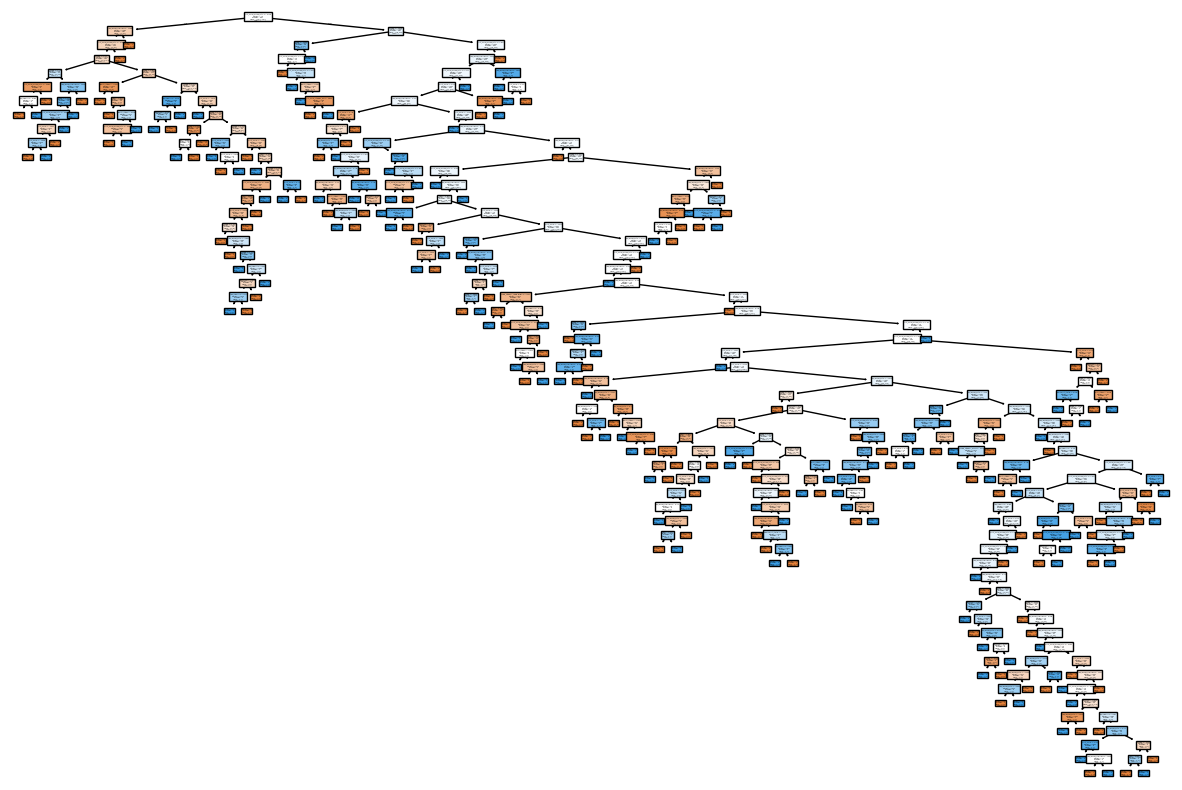

In [37]:
#plot
plt.figure(figsize=(15, 10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['0', '1'])
plt.show()

In [38]:
#Polynomial Features:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)




In [39]:
X_train_poly

array([[ 1.        , -0.12149869,  1.09560164, ...,  0.24416796,
        -1.64786034, 11.12121212],
       [ 1.        , -1.4818759 , -1.49391776, ...,  0.24416796,
         0.14817273,  0.08991826],
       [ 1.        ,  1.4429351 ,  0.19539349, ...,  0.24416796,
         0.14817273,  0.08991826],
       ...,
       [ 1.        ,  0.49067105, -0.79440093, ...,  0.24416796,
         0.14817273,  0.08991826],
       [ 1.        ,  1.30689738, -1.12107619, ...,  0.24416796,
         0.14817273,  0.08991826],
       [ 1.        , -0.12149869, -1.43996437, ...,  4.0955414 ,
        -0.60684754,  0.08991826]])

In [40]:
# Create new column names for the polynomial features
poly_features = poly.get_feature_names_out(input_features=X.columns)
    # Add the polynomial features to the DataFrame
df_poly = pd.DataFrame(X_train_poly, columns=poly_features)




In [41]:
print(df_poly)

       1       Age    Income  Education  Employment_Status  Marital_Status  \
0    1.0 -0.121499  1.095602   0.460876          -1.186687       -0.467823   
1    1.0 -1.481876 -1.493918  -1.324599           0.043040        0.423269   
2    1.0  1.442935  0.195393  -1.324599           0.043040        1.314360   
3    1.0 -1.005744  0.202590   0.460876          -1.186687       -1.358915   
4    1.0  0.694728 -1.475458  -0.431862           0.043040       -0.467823   
..   ...       ...       ...        ...                ...             ...   
795  1.0 -1.753951  1.499592   1.353613           0.043040        1.314360   
796  1.0 -1.345838  0.264608   1.353613          -1.186687       -0.467823   
797  1.0  0.490671 -0.794401  -0.431862           1.272768        0.423269   
798  1.0  1.306897 -1.121076  -0.431862          -1.186687        1.314360   
799  1.0 -0.121499 -1.439964   1.353613           1.272768       -0.467823   

     Credit_Score  Age_Income_Combined  Age_Squared  Age_Income

In [42]:
df=pd.concat([df,df_poly],axis=1)
df

,Age,Income,Education,Employment_Status,Marital_Status,Credit_Score,Loan_Approval,Age_Income_Combined,Age_Squared,Age_Income_Ratio,...,Income_Category_High^2,Income_Category_High Credit_Score_Category_Fair,Income_Category_High Credit_Score_Category_Good,Income_Category_High Credit_Score_Category_Excellent,Credit_Score_Category_Fair^2,Credit_Score_Category_Fair Credit_Score_Category_Good,Credit_Score_Category_Fair Credit_Score_Category_Excellent,Credit_Score_Category_Good^2,Credit_Score_Category_Good Credit_Score_Category_Excellent,Credit_Score_Category_Excellent^2
0,56,54674,0,1,0,427,1,3061744,3136,0.001024,...,0.0,-0.0,-0.0,0.0,0.219512,0.231512,-1.562447,0.244168,-1.647860,11.121212
1,69,55854,2,1,1,751,0,3853926,4761,0.001235,...,0.0,-0.0,-0.0,-0.0,0.219512,0.231512,0.140493,0.244168,0.148173,0.089918
2,46,66271,3,0,2,668,1,3048466,2116,0.000694,...,0.0,0.0,-0.0,-0.0,4.555556,-1.054666,-0.640022,0.244168,0.148173,0.089918
3,32,93688,1,0,0,342,0,2998016,1024,0.000342,...,0.0,-0.0,-0.0,-0.0,0.219512,0.231512,0.140493,0.244168,0.148173,0.089918
4,60,58518,3,1,3,718,0,3511080,3600,0.001025,...,0.0,-0.0,-0.0,-0.0,0.219512,0.231512,0.140493,0.244168,0.148173,0.089918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,118393,1,1,1,675,0,7103580,3600,0.000507,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,64,70861,3,1,0,746,0,4535104,4096,0.000903,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,62,95897,1,1,3,405,1,5945614,3844,0.000647,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,35,101905,3,0,3,700,0,3566675,1225,0.000343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
from sklearn.model_selection import cross_val_score
    # Example using Decision Tree with cross-validation
clf = DecisionTreeClassifier(random_state=42)
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree Accuracy: {scores.mean()}")
print(f"Decision Tree Accuracy Standard Deviation: {scores.std()}")
print(f"Decision Tree Accuracy Standard Deviation: {scores.std()}")
print("Average accuracy:", scores.mean())


Decision Tree Accuracy: 0.5175
Decision Tree Accuracy Standard Deviation: 0.015512092057488566
Decision Tree Accuracy Standard Deviation: 0.015512092057488566
Average accuracy: 0.5175


In [44]:
import xgboost as xgb
    # Create and train an XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
    # Make predictions on the test set
    # Make predictions on the test set
y_pred = xgb_model.predict(X_test)
    # Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy}")



XGBoost Accuracy: 0.5


In [45]:
#random forest
from sklearn.ensemble import RandomForestClassifier
# Instead of 'cross_val', use 'cross_val_score'
from sklearn.model_selection import cross_val_score
clf = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Random Forest Accuracy: {scores.mean()}")
print(f"Random Forest Accuracy Standard Deviation: {scores.std()}")

Random Forest Accuracy: 0.50875
Random Forest Accuracy Standard Deviation: 0.021139418156609704


In [49]:
#building decsion tree calssifier (cart) using gini cretria
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [50]:
#gini score
clf.score(X_train, y_train)
clf.score(X_train, y_train)


1.0

In [51]:
#predicted and computing the accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.455


In [52]:
np.mean(y_pred==y_test)

0.455

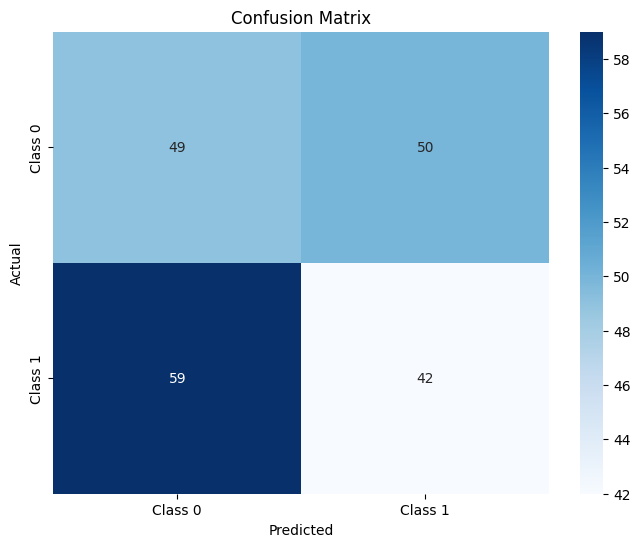

In [53]:
#confusion matrix plot
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

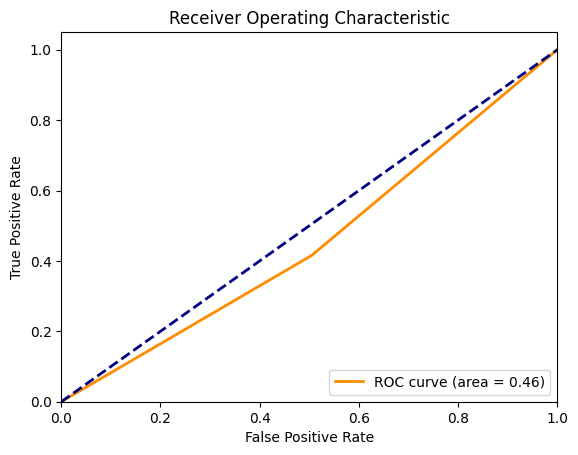

In [56]:
#ROC Curve (Receiver Operating Characteristic Curve):
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()



In [57]:
#GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Best Parameters: {best_params}")
print(f"Accuracy with Best Parameters: {accuracy}")


Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy with Best Parameters: 0.455
